In [1]:
import pandas as pd
import numpy as np
import sys
import os
import json
notebook_dir = os.getcwd() 
src_path = os.path.abspath(os.path.join(notebook_dir, '..'))
project_path = os.path.abspath(os.path.join(src_path, '..'))
sys.path.append(src_path)
sys.path.append(project_path)
from src.database import DatabaseManager
import pyarrow.parquet as pq
db = DatabaseManager()

In [2]:
draft_features = pd.read_parquet(f'{project_path}/data/alpha_20_window_3.parquet')

In [3]:
query_matches = '''
    SELECT id as match_id, "gameVersionId", "didRadiantWin"
    FROM match_details
'''
matches = db.select_to_df(query_matches)

query_ratings = '''
    WITH team_stats AS (
        SELECT 
            match_id,
            is_radiant,
            AVG(mu) as avg_mu,
            STDDEV(mu) as std_mu,
            MAX(mu) as max_mu,
            SUM(sigma) as total_sigma
        FROM rating_history
        GROUP BY match_id, is_radiant
    )
    SELECT 
        r.match_id,
        r.avg_mu as radiant_avg_mu, 
        r.std_mu as radiant_std_mu, 
        r.max_mu as radiant_max_mu, 
        r.total_sigma as radiant_total_sigma,
        d.avg_mu as dire_avg_mu, 
        d.std_mu as dire_std_mu, 
        d.max_mu as dire_max_mu, 
        d.total_sigma as dire_total_sigma
    FROM team_stats r
    JOIN team_stats d ON r.match_id = d.match_id
    WHERE r.is_radiant = true AND d.is_radiant = false;
'''
ratings = db.select_to_df(query_ratings)

df = pd.merge(matches, ratings, on='match_id', how='inner')

df_full = df.dropna(subset=[
    'radiant_avg_mu', 'dire_avg_mu', 
    'gameVersionId'
]).copy()

df_full.fillna(0, inplace=True)

df_full = pd.merge(
    df_full,
    draft_features,
    on='match_id'
)

df_full = df_full.rename(columns={
    'radiant_avg_mu': 'mu_rad',
    'dire_avg_mu': 'mu_dire',
    'radiant_std_mu': 'std_mu_rad',
    'dire_std_mu': 'std_mu_dire',
    'radiant_max_mu': 'max_mu_rad',
    'dire_max_mu': 'max_mu_dire',
    'radiant_total_sigma': 'sigma_total_rad',
    'dire_total_sigma': 'sigma_total_dire'
})
df_full['mu_diff'] = df_full['mu_rad'] - df_full['mu_dire']
df_full['std_diff'] = df_full['std_mu_rad'] - df_full['std_mu_dire']
df_full['max_mu_diff'] = df_full['max_mu_rad'] - df_full['max_mu_dire']
df_full['sigma_total_diff'] = df_full['sigma_total_rad'] - df_full['sigma_total_dire']

In [4]:
df_train = df_full[(df_full['gameVersionId'] <= 178) & (df_full['gameVersionId'] > 72)].copy()
df_test = df_full[(df_full['gameVersionId'] > 178) & (df_full['gameVersionId'] > 72)].copy()
with open(f'{project_path}/config/features.json', 'r') as f: 
    features = sorted(json.load(f))
X_train = df_train[features].values
X_test = df_test[features].values
y_train = df_train['didRadiantWin'].astype('int').values
y_test = df_test['didRadiantWin'].astype('int').values

In [5]:
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
from sklearn.metrics import brier_score_loss
def expected_calibration_error(y_true, y_prob, n_bins=10):
    """
    Calculates ECE: the weighted average difference between predicted and actual win rates.
    """
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy='uniform')
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_counts = np.histogram(y_prob, bins=bin_edges)[0]
    non_empty_indices = bin_counts > 0
    
    filtered_prob_true = prob_true[non_empty_indices]
    filtered_prob_pred = prob_pred[non_empty_indices]
    filtered_counts = bin_counts[non_empty_indices]
    
    bin_weights = filtered_counts / np.sum(filtered_counts)
    ece = np.sum(bin_weights * np.abs(filtered_prob_true - filtered_prob_pred))
    
    return ece

def brier_skill_score(y_true, y_prob):
    """
    Normalized improvement over always guessing 0.5.
    """
    brier_model = brier_score_loss(y_true, y_prob)
    brier_baseline = brier_score_loss(y_true, np.full_like(y_true, 0.5, dtype=float))
    return 1 - (brier_model / brier_baseline)

In [6]:
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


tscv = TimeSeriesSplit(n_splits=5)

lr_auc_scores, lr_acc_scores = [], []
lgb_auc_scores, lgb_acc_scores = [], []
lgb_brier_scores, lgb_ece_scores = [], []

oof_preds = np.zeros(len(X_train))
oof_idx = [] 

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    
    oof_idx.extend(val_idx)
    
    log_reg_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, solver='saga', random_state=42))
    ])
    log_reg_pipeline.fit(X_tr, y_tr)
    fold_lr_preds = log_reg_pipeline.predict_proba(X_val)[:, 1]
    
    lr_auc_scores.append(roc_auc_score(y_val, fold_lr_preds))
    lr_acc_scores.append(accuracy_score(y_val, (fold_lr_preds >= 0.5).astype(int)))
    
    lgb_train = lgb.Dataset(X_tr, label=y_tr, feature_name=features)
    lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train, feature_name=features)
    
    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'boosting_type': 'gbdt',
        'learning_rate': 0.03,
        'num_leaves': 31,
        'max_depth': 5,         
        'feature_fraction': 0.8,
        'verbosity': -1,
        'seed': 42
    }
    
    model = lgb.train(
        params,
        lgb_train,
        num_boost_round=1000,
        valid_sets=[lgb_val],
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )
    
    fold_lgb_preds = model.predict(X_val, num_iteration=model.best_iteration)
    oof_preds[val_idx] = fold_lgb_preds
    
    lgb_auc_scores.append(roc_auc_score(y_val, fold_lgb_preds))
    lgb_acc_scores.append(accuracy_score(y_val, (fold_lgb_preds >= 0.5).astype(int)))
    lgb_brier_scores.append(brier_score_loss(y_val, fold_lgb_preds))
    lgb_ece_scores.append(expected_calibration_error(y_val, fold_lgb_preds))
    
    print(f"[Fold {fold+1}] LGB AUC: {lgb_auc_scores[-1]:.4f} | Brier: {lgb_brier_scores[-1]:.4f} | ECE: {lgb_ece_scores[-1]:.4f}")


[Fold 1] LGB AUC: 0.6795 | Brier: 0.2237 | ECE: 0.0133
[Fold 2] LGB AUC: 0.6937 | Brier: 0.2202 | ECE: 0.0208
[Fold 3] LGB AUC: 0.6842 | Brier: 0.2223 | ECE: 0.0108
[Fold 4] LGB AUC: 0.6849 | Brier: 0.2226 | ECE: 0.0193
[Fold 5] LGB AUC: 0.6629 | Brier: 0.2272 | ECE: 0.0151


Mean LGB AUC:  0.6810
Mean Brier:    0.2232
Mean ECE:      0.0159

--- Hold-Out Test Set (Unseen Data) ---
Hold-Out AUC:  0.6503
Hold-Out ECE:  0.0188
--- Calibration comparison on test set ---
                          Raw   Isotonic    Platt
Brier score            0.2297     0.2297   0.2299
ECE                    0.0173     0.0188   0.0197


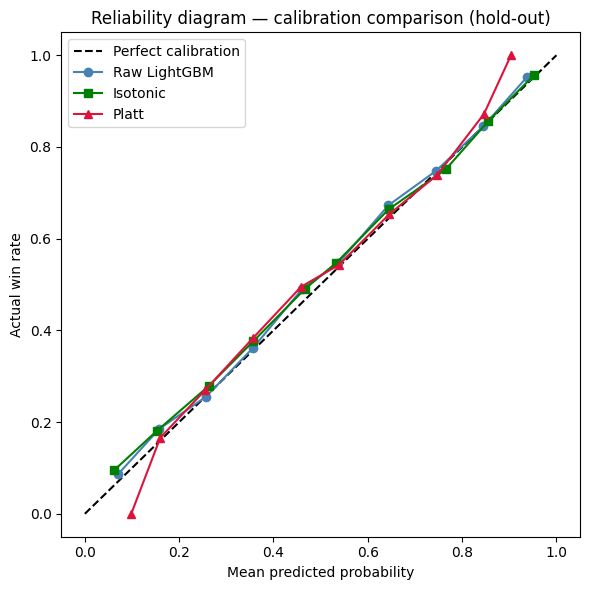

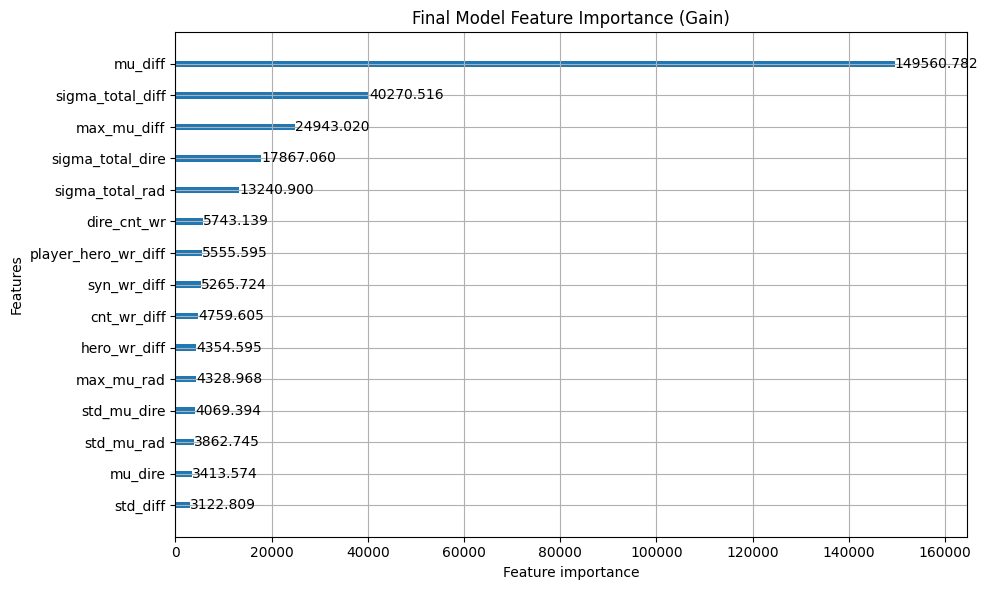

In [7]:
from sklearn.isotonic import IsotonicRegression

iso_reg = IsotonicRegression(out_of_bounds='clip')
iso_reg.fit(oof_preds[oof_idx], y_train[oof_idx])
platt = LogisticRegression()
platt.fit(oof_preds[oof_idx].reshape(-1, 1), y_train[oof_idx])

test_raw_preds = model.predict(X_test)
test_calibrated_preds = iso_reg.predict(test_raw_preds)
test_platt_preds = platt.predict_proba(test_raw_preds.reshape(-1, 1))[:, 1]

print(f"Mean LGB AUC:  {np.mean(lgb_auc_scores):.4f}")
print(f"Mean Brier:    {np.mean(lgb_brier_scores):.4f}")
print(f"Mean ECE:      {np.mean(lgb_ece_scores):.4f}")

print("\n--- Hold-Out Test Set (Unseen Data) ---")
print(f"Hold-Out AUC:  {roc_auc_score(y_test, test_calibrated_preds):.4f}")
print(f"Hold-Out ECE:  {expected_calibration_error(y_test, test_calibrated_preds):.4f}")

raw_brier = brier_score_loss(y_test, test_raw_preds)
raw_ece   = expected_calibration_error(y_test, test_raw_preds)

cal_brier = brier_score_loss(y_test, test_calibrated_preds)
cal_ece   = expected_calibration_error(y_test, test_calibrated_preds)

platt_brier = brier_score_loss(y_test, test_platt_preds)
platt_ece   = expected_calibration_error(y_test, test_platt_preds)

print("--- Calibration comparison on test set ---")
print(f"{'':20s} {'Raw':>8} {'Isotonic':>10} {'Platt':>8}")
print(f"{'Brier score':20s} {raw_brier:>8.4f} {cal_brier:>10.4f} {platt_brier:>8.4f}")
print(f"{'ECE':20s} {raw_ece:>8.4f} {cal_ece:>10.4f} {platt_ece:>8.4f}")

prob_true_platt, prob_pred_platt = calibration_curve(y_test, test_platt_preds, n_bins=10, strategy='uniform')
prob_true_raw, prob_pred_raw = calibration_curve(y_test, test_raw_preds, n_bins=10, strategy='uniform')
prob_true_cal, prob_pred_cal = calibration_curve(y_test, test_calibrated_preds, n_bins=10, strategy='uniform')

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(prob_pred_raw,   prob_true_raw,   'o-', color='steelblue', label='Raw LightGBM')
ax.plot(prob_pred_cal,   prob_true_cal,   's-', color='green',     label='Isotonic')
ax.plot(prob_pred_platt, prob_true_platt, '^-', color='crimson',   label='Platt')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Actual win rate')
ax.set_title('Reliability diagram — calibration comparison (hold-out)')
ax.legend()
plt.tight_layout()
plt.show()

lgb.plot_importance(model, max_num_features=15, importance_type='gain', figsize=(10, 6), title="Final Model Feature Importance (Gain)")
plt.tight_layout()
plt.show()

In [8]:
counts, _ = np.histogram(test_calibrated_preds, bins=10)
print("Samples per bin:", counts)

Samples per bin: [  158   861  2105  2772 13528  9024  3912  1812  1039   352]


In [13]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'seed': 42,

        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'min_data_in_leaf':  trial.suggest_int('min_data_in_leaf', 20, 200),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq':      trial.suggest_int('bagging_freq', 1, 7),
        'lambda_l1':         trial.suggest_float('lambda_l1', 1e-4, 10.0, log=True),
        'lambda_l2':         trial.suggest_float('lambda_l2', 1e-4, 10.0, log=True),
        'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.0, 0.5),
    }

    fold_aucs = []
    for train_idx, val_idx in tscv.split(X_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        lgb_tr = lgb.Dataset(X_tr, label=y_tr, feature_name=sorted(features))
        lgb_v  = lgb.Dataset(X_val, label=y_val, reference=lgb_tr)

        m = lgb.train(
            params, lgb_tr,
            num_boost_round=1000,
            valid_sets=[lgb_v],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )
        preds = m.predict(X_val, num_iteration=m.best_iteration)
        fold_aucs.append(roc_auc_score(y_val, preds))

    return np.mean(fold_aucs)

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Best AUC:    {study.best_value:.4f}")

Best trial: 36. Best value: 0.681855: 100%|██████████| 50/50 [22:34<00:00, 27.09s/it]

Best AUC:    0.6819


In [14]:
best_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'seed': 42,
    **study.best_params
}

final_model_tuned = lgb.train(
    best_params,
    lgb.Dataset(X_train, label=y_train, feature_name=sorted(features)),
    num_boost_round=model.best_iteration 
)

test_preds_tuned = final_model_tuned.predict(X_test)

print("--- Tuned model vs baseline on hold-out ---")
print(f"{'':20s} {'Baseline':>10} {'Tuned':>8}")
print(f"{'AUC':20s} {roc_auc_score(y_test, test_raw_preds):>10.4f} {roc_auc_score(y_test, test_preds_tuned):>8.4f}")
print(f"{'Brier':20s} {brier_score_loss(y_test, test_raw_preds):>10.4f} {brier_score_loss(y_test, test_preds_tuned):>8.4f}")
print(f"{'ECE':20s} {raw_ece:>10.4f} {expected_calibration_error(y_test, test_preds_tuned):>8.4f}")

--- Tuned model vs baseline on hold-out ---
                       Baseline    Tuned
AUC                      0.6506   0.6518
Brier                    0.2297   0.2295
ECE                      0.0173   0.0210


In [15]:
from pathlib import Path
import joblib
model_file_path = Path(project_path) / 'src' / 'ml_models' / 'tuned_model.joblib'
joblib.dump(final_model_tuned, model_file_path)
print(f'Model saved to destination .../{model_file_path.parent.name}/{model_file_path.name}')

Model saved to destination .../ml_models/tuned_model.joblib
